# [Classification of oil and gas](https://www.kaggle.com/competitions/classification-of-oil-and-gas)

In [61]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
import opendatasets as od

dataset_url = 'https://www.kaggle.com/competitions/classification-of-oil-and-gas'
od.download(dataset_url)

Skipping, found downloaded files in "./classification-of-oil-and-gas" (use force=True to force download)


In [63]:
train = pd.read_csv('./classification-of-oil-and-gas/train_oil.csv')
test = pd.read_csv('./classification-of-oil-and-gas/oil_test.csv')

train

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,HIDES,IMBURU-TORO,PAPUA NEW GUINEA,FAR EAST,PAPUAN FTB,COMPRESSION,-6.0136,142.8409,OIL SEARCH LTD,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0
305,DRAKE POINT,DRAKE POINT-INTREPID INLET,CANADA,NORTH AMERICA,SVERDRUP,COMPRESSION/EVAPORITE/EXTENSION/LINKED,76.4462,-108.9172,PANARCTIC OILS,ONSHORE,GAS,UNDEVELOPED,FORELAND,3390,JURASSIC,SANDSTONE,100.0,71.0,20.0,566.0
306,ALTAMONT-BLUEBELL,GREEN RIVER AND COLTON/WASATCH,USA,NORTH AMERICA,UINTA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,BELL CREEK,MUDDY,USA,NORTH AMERICA,POWDER RIVER,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


## Visualization

In [64]:
from folium import Marker, Map, Icon
map = Map()

for idx, row in train.iterrows():
    if pd.notna(row['Latitude']) and pd.notna(row['Longitude']):
        Marker(location=[row['Latitude'], row['Longitude']], popup=row["Onshore/Offshore"], icon=Icon(color='green')).add_to(map)

for idx, row in test.iterrows():
    if pd.notna(row['Latitude']) and pd.notna(row['Longitude']):
        Marker(location=[row['Latitude'], row['Longitude']], icon=Icon(color='orange')).add_to(map)

map


<Axes: xlabel='Onshore/Offshore', ylabel='count'>

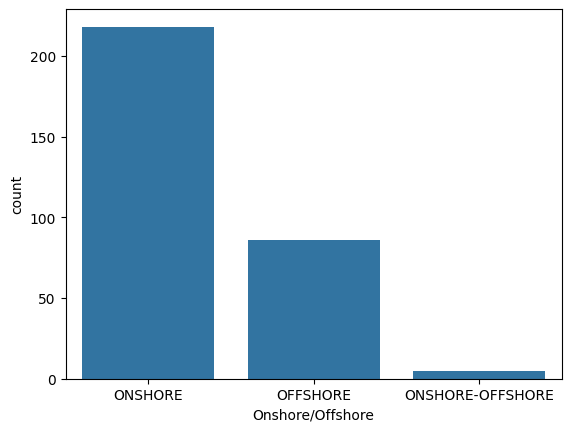

In [65]:
sns.countplot(x="Onshore/Offshore", data=train)

## Main part

In [66]:
train

,Field name,Reservoir unit,Country,Region,Basin name,Tectonic regime,Latitude,Longitude,Operator company,Onshore/Offshore,Hydrocarbon type,Reservoir status,Structural setting,Depth,Reservoir period,Lithology,Thickness (gross average ft),Thickness (net pay average ft),Porosity,Permeability
0,ZHIRNOV,MELEKESKIAN,RUSSIA,FORMER SOVIET UNION,VOLGA-URAL,COMPRESSION/EVAPORITE,51.0000,44.8042,NIZHNEVOLZHSKNET,ONSHORE,OIL,DECLINING PRODUCTION,FORELAND,1870,CARBONIFEROUS,SANDSTONE,262.0,33.0,24.0,30.0
1,LAGOA PARDA,LAGOA PARDA (URUCUTUCA),BRAZIL,LATIN AMERICA,ESPIRITO SANTO,EXTENSION,-19.6017,-39.8332,PETROBRAS,ONSHORE,OIL,NEARLY DEPLETED,PASSIVE MARGIN,4843,PALEOGENE,SANDSTONE,2133.0,72.0,23.0,350.0
2,ABQAIQ,ARAB D,SAUDI ARABIA,MIDDLE EAST,THE GULF,COMPRESSION/EVAPORITE,26.0800,49.8100,SAUDI ARAMCO,ONSHORE,OIL,REJUVENATING,FORELAND,6050,JURASSIC,LIMESTONE,250.0,184.0,21.0,410.0
3,MURCHISON,BRENT,UK /NORWAY,EUROPE,NORTH SEA NORTHERN,EXTENSION,61.3833,1.7500,CNR,OFFSHORE,OIL,NEARLY DEPLETED,RIFT,8988,JURASSIC,SANDSTONE,425.0,300.0,22.0,750.0
4,WEST PEMBINA,NISKU (PEMBINA L POOL),CANADA,NORTH AMERICA,WESTERN CANADA,COMPRESSION,53.2287,-115.8008,NUMEROUS,ONSHORE,OIL,UNKNOWN,FORELAND,9306,DEVONIAN,DOLOMITE,233.0,167.0,11.8,1407.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
304,HIDES,IMBURU-TORO,PAPUA NEW GUINEA,FAR EAST,PAPUAN FTB,COMPRESSION,-6.0136,142.8409,OIL SEARCH LTD,ONSHORE,GAS-CONDENSATE,CONTINUING DEVELOPMENT,THRUST,9905,JURASSIC-CRETACEOUS,SANDSTONE,490.0,240.0,10.0,100.0
305,DRAKE POINT,DRAKE POINT-INTREPID INLET,CANADA,NORTH AMERICA,SVERDRUP,COMPRESSION/EVAPORITE/EXTENSION/LINKED,76.4462,-108.9172,PANARCTIC OILS,ONSHORE,GAS,UNDEVELOPED,FORELAND,3390,JURASSIC,SANDSTONE,100.0,71.0,20.0,566.0
306,ALTAMONT-BLUEBELL,GREEN RIVER AND COLTON/WASATCH,USA,NORTH AMERICA,UINTA,COMPRESSION,40.3000,-110.2100,NUMEROUS,ONSHORE,OIL,MATURE PRODUCTION,FORELAND,15250,PALEOGENE,SANDSTONE,8000.0,575.0,5.0,0.1
307,BELL CREEK,MUDDY,USA,NORTH AMERICA,POWDER RIVER,COMPRESSION,45.1039,-105.0967,SAMUEL GARY,ONSHORE,OIL,NEARLY DEPLETED,FORELAND,4300,CRETACEOUS,SANDSTONE,45.0,23.0,28.5,2250.0


In [67]:
def preprocessing(df: pd.DataFrame, fit: bool=False) -> pd.DataFrame:
    category_columns = ["Region", "Basin name", "Operator company",
                        "Hydrocarbon type", "Reservoir status", 
                        "Reservoir period", "Lithology"]
    for column in category_columns:
        df[column] = df[column].astype("category")

    df['Country'] = df['Country'].str.split(' /')
    df['Tectonic regime'] = df['Tectonic regime'].str.split('/')
    df['Operator company'] = df['Operator company'].str.split(' /')
    df['Structural setting'] = df['Structural setting'].str.split('/')

    if fit:
        mapping = {'ONSHORE': 1, 'OFFSHORE': 0, 'ONSHORE-OFFSHORE': 2}
        df['Onshore/Offshore'] = df['Onshore/Offshore'].map(mapping)

    return df

def fulling_nan(df: pd.DataFrame) -> pd.DataFrame:
    df['Country'] = df['Country'].fillna('Unknown')
    df['Region'] = df['Region'].fillna('Unknown')
    df['Basin name'] = df['Basin name'].fillna('Unknown')

    return df

from sklearn.preprocessing import MultiLabelBinarizer, OneHotEncoder
multis = {}
for column in ['Country', 'Tectonic regime', 'Operator company', 'Structural setting']:
    multis[column] = MultiLabelBinarizer()
ones = {}
for column in ['Region', 'Basin name', 'Hydrocarbon type', 'Reservoir status', 'Reservoir period', 'Lithology']:
    ones[column] = OneHotEncoder(handle_unknown='infrequent_if_exist')

def expanding(data: pd.DataFrame, fit: bool=False) -> pd.DataFrame:
    if fit:
        for column, multi in multis.items():
            multi.fit(data[column])
        for column, one in ones.items():
            one.fit(data[[column]])

    for column, multi in multis.items():
        transformed = multi.transform(data[column])
        col_names = [f"{column}__{cls}" for cls in multi.classes_]
        df_transformed = pd.DataFrame(transformed, columns=col_names, index=data.index)
        data = pd.concat([data, df_transformed], axis=1)
        data = data.drop(columns=[column])

    for column, one in ones.items():
        transformed = one.transform(data[[column]]).toarray()
        col_names = [f"{column}__{cat}" for cat in one.categories_[0]]
        df_transformed = pd.DataFrame(transformed, columns=col_names, index=data.index)
        data = pd.concat([data, df_transformed], axis=1)
        data = data.drop(columns=[column])

    return data

from sklearn.preprocessing import StandardScaler
std = StandardScaler()

def scaling(data: pd.DataFrame, fit: bool=False) -> pd.DataFrame:
    data_columns = data.columns.drop("Onshore/Offshore", errors='ignore')

    if fit:
        scaled_values = std.fit_transform(data[data_columns])
    else:
        scaled_values = std.transform(data[data_columns])

    data_scaled = pd.DataFrame(scaled_values, columns=data_columns, index=data.index)
    if fit:
        data_scaled["Onshore/Offshore"] = data["Onshore/Offshore"]

    return data_scaled

from imblearn.over_sampling import RandomOverSampler, SMOTE
def sampling(df: pd.DataFrame, fit: bool=False) -> pd.DataFrame:
    if fit:
        X, y = df.drop(columns=["Onshore/Offshore"]), df["Onshore/Offshore"]
        sm = SMOTE(sampling_strategy='auto', random_state=42, k_neighbors=2)
        X_resampled, y_resampled = sm.fit_resample(X, y)
        y_resampled = pd.Series(y_resampled, name="Onshore/Offshore")
        df = pd.concat([pd.DataFrame(X_resampled, columns=X.columns), y_resampled], axis=1)
        df.reset_index(drop=True, inplace=True)
    return df

In [68]:
def pipeline(df: pd.DataFrame, fit: bool=False) -> pd.DataFrame:
    df = df.copy()

    df = df.drop(columns=['Field name', 'Reservoir unit'])
    df = fulling_nan(df)
    df = preprocessing(df, fit)
    df = df.drop(columns=['Latitude', 'Longitude'])
    df = expanding(df, fit)
    df = scaling(df, fit)
    df = sampling(df, fit)

    return df

In [69]:
from sklearn.linear_model import LogisticRegression

train = pipeline(train, fit=True)
test = pipeline(test)

logreg = LogisticRegression()
logreg.fit(train.drop(columns=["Onshore/Offshore"]), train["Onshore/Offshore"])
result = logreg.predict(test)

/home/andredon/projects/University/25AIMEPhI/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['AUSTRIA', 'BAHRAIN', 'ECUADOR', 'GERMANY', 'KUWAIT', 'MAURITANIA', 'NETHERLANDS'] will be ignored
  warnings.warn(
/home/andredon/projects/University/25AIMEPhI/.venv/lib/python3.12/site-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['BAHRAIN NATIONAL OIL CO', 'CASTLE PEAK RESOURCES', 'COASTAL', 'CRESTAR ENERGY', 'CRONUS DEVELOPMENT', 'DNS', 'FOREST OIL', 'GAZPROM (YAMBURGGAZDOBYCHA)', 'HOWELL PETROLEUM AND OTHERS', 'HUMBLE', 'KARAZHANBASMUNAI', 'KERR MCGEE AND OTHERS', 'KERR-MCGEE', 'KHALDA PETROLEUM', 'KINDER MORGAN', 'KUWAIT OIL CO', 'MASTERS ENERGY', 'NAM', 'NATIONS ENERGY', 'NIZHNEVOLZHSKNEFT', 'NORILSKGAZPROM', 'NUMAC ENERGY', 'ODESSA EXPLORATION', 'OMV', 'ORIGIN ENERGY', 'PETROBEL', 'PETROCHINA INTERNATIONAL', 'PETROECUADOR (PETROPRODUCTION)', 'PHILLIPS', 'PLACID OIL', 'POCO PETROLEUM', 'PURE OIL COMPA

<Axes: xlabel='count'>

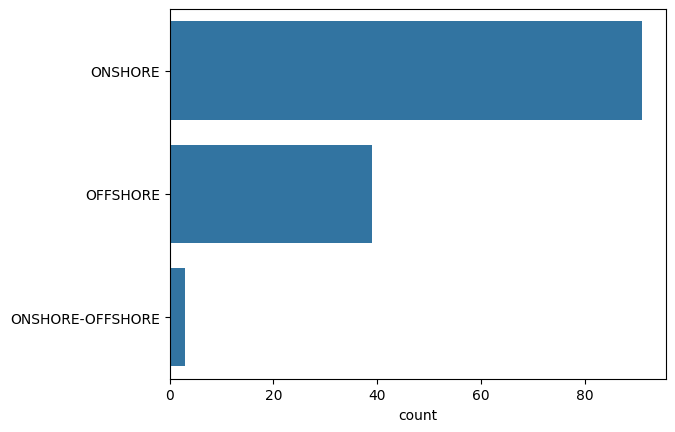

In [70]:
sns.countplot(data=np.vectorize({1: 'ONSHORE', 0: 'OFFSHORE', 2: 'ONSHORE-OFFSHORE'}.get)(result))

In [71]:
pd.Series(result, name="Onshore/Offshore").reset_index().to_csv('./classification-of-oil-and-gas/result.csv', index=False)

In [72]:
!kaggle competitions submit -c classification-of-oil-and-gas -f ./classification-of-oil-and-gas/result.csv -m "Message"

401 Client Error: Unauthorized for url: https://www.kaggle.com/api/v1/competitions/submission-url
